# ADAaptative LInear NEurons y regresión logística

> Material basado en el libro *Machine Learning with PyTorch and Scikit-Learn - Raschka et al. 2022* capítulo 2-3

## Objetivos

- Abordar una arquitectura neuronal de una sola capa distinta al perceptron: Adaline
    - Ver la función de minimización: *Descenso del gradiente (Gradient Descent, GD)*
    - Implementar Adaline en python
- Con base en Adaline implementar la regresión lógistica

## Adaline

- La arquitectura que siguió los pasos del Perceptron fue la **ADAptative LInear NEuron (Adaline)** que fue publicada unos años después por *Bernard Widrow (An Adaptive “Adaline” Neuron Using Chemical “Memistors”, Technical Report Number 1553-2 by B. Widrow and colleagues, Stanford Electron Labs, Stanford, CA, October 1960)*
- Adaline ilustra los conceptos de minimización de la perdida de una función continua. Este concepto es fundamental para comprender otros métodos de aprendizaje como la **regresión logística**.
- La diferencia principal entre el perceptron y Adaline está en la actualización de pesos. Esta actualización se da con base en la función lineal en lugar de la función escalon unitario. En ese sentido, la función de activación de Adaline será la identidad de la entrada a la red: $\sigma(z) = z$

<center><img src="img/perceptron_adaline.png" width=500></center>

> Tomada de ML con Pytorch y Scikit-Learn, Raschka et. al 

### ❓ Porqué seguimos teniendo la función escalon unitario

Si bien la función líneal será necesaria para aprender los pesos de la red, seguiremos necesitando la función escalon para tomar la desición de clasificación del ejemplo en turno

### Minimizando la perdida

- Como vimos en clases anteriores, definir nuestro problema en terminos de *ML* implica identificar la función objetivo que vamos a minimizar
- En el caso de Adaline la función *loss* ($L$) será el **error cuadrático medio (Mean Squared error, MSE)** entre la predicción y la etiqueta real

$$
L(\textbf{w},b)=\frac{1}{2n}\sum_{i=1}^{n}(y^{(i)}-\sigma(z^{(i)}))^2
$$

### ❓ Que ventajas encuentran con respecto a la función de activación del perceptron y la forma de calcular el error?

- La función de activación lineal es continua, en contraste con la función escalón, lo que la hace diferenciable
- La función de *loss* es convexa, por lo tanto, podemos utilizar el **decenso del gradiente** para optimizar los pesos y minimizarla

### Descenso del gradiente (GD)

<center><img src="img/gd.png" width=500></center>

> Tomada de ML con Pytorch y Scikit-Learn, Raschka et. al 

<center><img src="https://baptiste-monpezat.github.io/4e5a14da749976ec2770eaded04098d4/gradient_descent.gif"></center>

#### Reglas de aprendizaje de Adaline

- Al utilizar el *GD* podemos actualizar los parámetros del modelo tomando la dirección opuesta al gradiente $\nabla L(\textbf{w},b)$
- En este caso, las deltas de $w$ y $b$ cambiaran:

$$
\begin{align}
    \Delta w = -\eta\nabla_w L(\textbf{w},b)\\
    \Delta b = -\eta\nabla_b L(\textbf{w},b)
\end{align}
$$
- Para calcular el gradiente de la función *loss (**MSE**)*, debemos computar las derivadas parciales de la función *loss* con respecto a $w_j$ (para los pesos) y con respecto a $b$ para el *bias*:

$$
\begin{align}
    \frac{\partial L}{\partial w_j} = - \frac{2}{n}\sum_{i}(y^{(i)}-\sigma(z^{(i)}))x^{(j)}\\
    \frac{\partial L}{\partial b} = - \frac{2}{n}\sum_{i}(y^{(i)}-\sigma(z^{(i)}))\\
\end{align}
$$

**NOTA:** el $2$ es un factor de escala que se obtiene de realizar la derivada parcial a la función *MSE*. Se dejará como ejercicio al lector realizar la derivada y comprobar que efectivamente es correcta :p

Entonces la actualización de pesos quedará de la siguiente forma:

$$
\begin{align}
    \Delta w = -\eta\frac{\partial L}{\partial w_j}\\
    \Delta b = -\eta\frac{\partial L}{\partial b}
\end{align}
$$

Con esto las reglas de aprendizaje de Adaline serán descritas por las siguientes ecuaciones:

$$
\begin{align}
    \textbf{w} = \textbf{w} + \Delta \textbf{w}\\
    b = b + \Delta b
\end{align}
$$

Notemos que aunque las reglas de aprendizaje de Adaline parecen ser identicas a las del perceptron, los resultados de $\sigma(z^{(i)})$ con  $z^{(i)}=\textbf{w}^T\textbf{x}^{(i)}+b$ es un número real y no solo un entero (`0|1`) como en el perceptron. Por lo tanto, los pesos serán actualizados con base en todos los ejemplos vistos en el entrenamiento (en lugar de una actualización incremental predición por predicción). Por esta razón a este enfoque se le conoce como **batch gradient decent**[^1]

[^1]: A diferencia del *Stochastic Gradient Decent, SGD* en este enfoque se toman en cuenta **todos** los ejemplos de entrenamiento. En futuras prácticas veremos la diferencia

### Code

In [4]:
import numpy as np
from numpy.random import RandomState
from rich import print

In [5]:
class AdalineGD:
    """Clasificador ADAptive LInear NEuron (ADALINE)

    Parameters
    ------------
    eta : float
      Learning rate (entre 0.0 y 1.0)
    epochs : int
      Numero de pasos para entrenamiento.
    random_state : int
      Semilla para el generador de número aleatorios para
      inicialización de pesos
    
    Attributes
    -----------
    w: 1d-array
      Pesos despues del entrenamiento
    b : Scalar
      Bias unit despues del entrenamiento
    errors : list
      Número de clases incorrectamente clasificadas para cada epoch
    """

    def __init__(self, eta=0.01, epochs=100, random_state=42, verbose=False):
        self.eta = eta
        self.epochs = epochs
        self.random_state = random_state
        self.errors = []
        self.verbose = verbose
        
    def fit(self, X: np.array, y: np.array):
        random_gen = RandomState(self.random_state)
        # Generamos números pequeños de una distribución normal
        # con std=0.01 y media=0.0
        self.w = random_gen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # El bias será inicializado en 0
        self.b = np.float64(0.)
        
        for _ in range(self.epochs):
            # Aplicar la función de entrada
            forward = self.forward(X)
            # Aplicar la función de activación
            out = self.activation(forward)
            # Obtener los errores
            epoch_errors = (y - out)
            # Actualización de pesos
            self.w += self.eta * 2.0 * X.T.dot(epoch_errors) / X.shape[0]
            self.b += self.eta * 2.0 * epoch_errors.mean()
            # Error Cuadrático medio
            loss = (epoch_errors ** 2).mean()
            if self.verbose:
                print(f"EPOCH: {_} loss: {loss} | w={self.w} | b={self.b}")        
            self.errors.append(loss)
        return self

    def forward(self, X: np.array):
        """Calcula la entrada de la red"""
        return np.dot(X, self.w) + self.b

    def activation(self, X: np.array):
        """Capa de activación"""
        return X

    def predict(self, X: np.array):
        """Función de decisión"""
        return np.where(self.forward(X) >= 0.5, 1, 0)

In [6]:
import pandas as pd
from sklearn.datasets import load_iris

def preprocess_iris_binary(categories: list[str]) -> tuple[np.array, np.array]:
    iris = load_iris(as_frame=True)
    df = iris.frame

    df = df[(df["target"] == 0) | (df["target"] == 1)] 
    y = df["target"]
    Y = y.to_numpy()
    x = df[categories]
    X = x.values
    return X, Y

In [7]:
X, y = preprocess_iris_binary(categories=["sepal length (cm)", "petal length (cm)"])

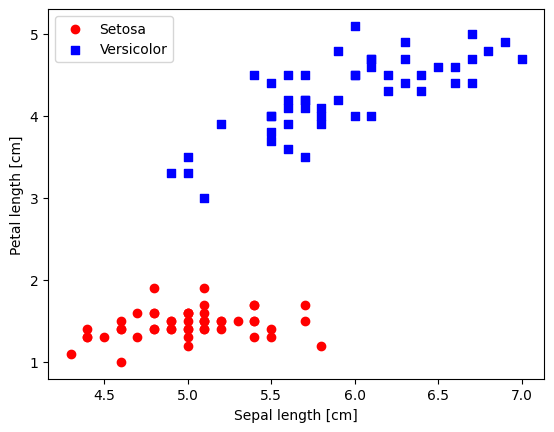

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='s', label='Versicolor')
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

### Ejercicio: 

- Juega con el *learning rate* $\eta$. Utiliza uno muy chico (`>= 0.0`) y uno muy grande (`=< 1.0`)
- Plotea los errores de ambos casos
- Analiza y discute con tu camarada que esta sucediendo

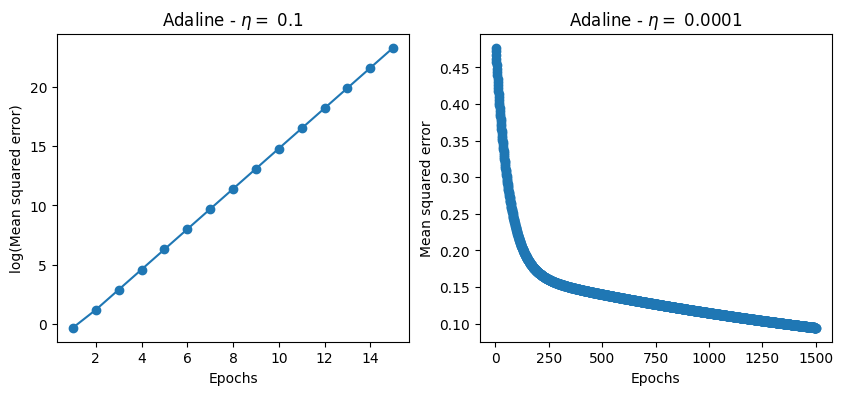

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# lr grande
ada1 = AdalineGD(epochs=15, eta=0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.errors) + 1), np.log10(ada1.errors), marker="o")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("log(Mean squared error)")
ax[0].set_title(r"Adaline - $\eta=$ 0.1")

# lr bajo
ada2 = AdalineGD(epochs=1500, eta=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.errors) + 1), ada2.errors, marker="o")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Mean squared error")
ax[1].set_title(r"Adaline - $\eta=$ 0.0001")
plt.show()

<center><img src="img/gd_lr.png"></center>

> Tomada de ML con Pytorch y Scikit-Learn, Raschka et. al 

In [10]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # setup marker generator and color map
    markers = ("o", "s", "^", "v", "<")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[: len(np.unique(y))])
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution)
    )
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colors[idx],
            marker=markers[idx],
            label=f"Class {cl}",
            edgecolor="black",
        )
    
    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c="none",
            edgecolor="black",
            alpha=1.0,
            linewidth=1,
            marker="o",
            s=100,
            label="Test set",
        )

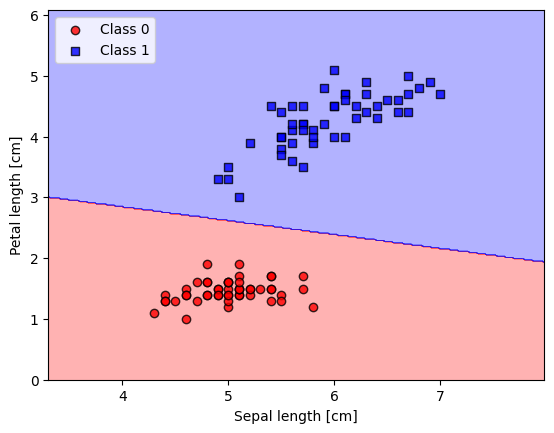

In [11]:
plot_decision_regions(X, y, classifier=ada2)
plt.xlabel("Sepal length [cm]")
plt.ylabel("Petal length [cm]")
plt.legend(loc="upper left")
plt.show()

### Normalización al rescate

![](https://gifdb.com/images/high/super-cow-and-chicken-daxvak1q16quwd9p.webp)

- Muchos algoritmos de *ML* se ven beneficiados de algun tipo de reescalado de *features*. *GD* es uno de ellos
- Podemos aplicar el método de escalado llamado **estandarización**. Esta normaliación ayuda a que el aprendizaje en el *GD* converja más rápido. La estandarización modificará cada *feature* de tal modo que centrará las medias en cero y la desviación estandar en uno. De este modo, si queremos estandarizar la *feature* $jth$ deberemos aplicar la siguiente ecuación:

$$
x'_j = \frac{x_j-\mu_j}{\sigma_j}
$$

### ❓ Porqué esto ayuda al GD a converger más rápido?

Normalizar ayuda a hacer que el *learning rate* funcione bien para todas las *features*.

In [12]:
X_norm = np.copy(X)
X_norm[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_norm[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()

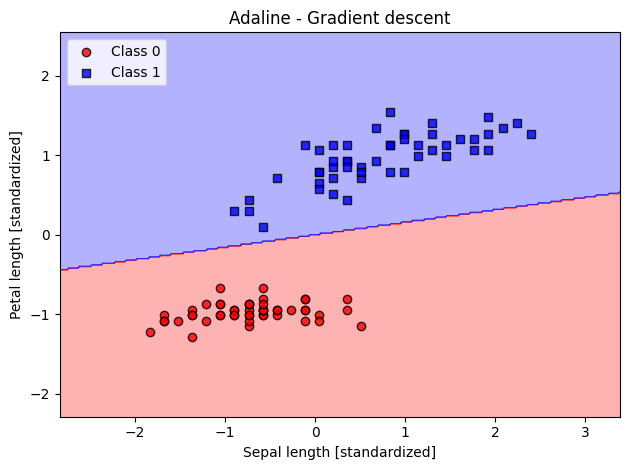

In [13]:
ada_gd = AdalineGD(epochs=10, eta=0.5, verbose=False)
ada_gd.fit(X_norm, y)
plot_decision_regions(X_norm, y, classifier=ada_gd)
plt.title("Adaline - Gradient descent")
plt.xlabel("Sepal length [standardized]")
plt.ylabel("Petal length [standardized]")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

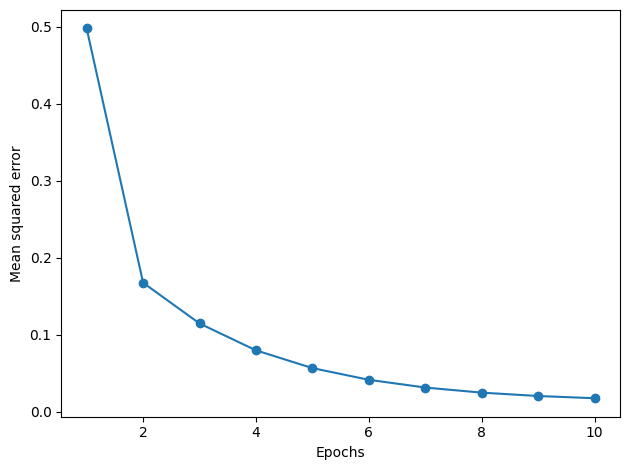

In [14]:
plt.plot(range(1, len(ada_gd.errors) + 1), ada_gd.errors, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Mean squared error")
plt.tight_layout()
plt.show()

## Modelando probabilidades de clases vía Regresión Logística

- Una de las principales desventajas del perceptron es que nunca converge si las clases no son linealmente separables. Esto es porque si hay almenos alguna clase que esté mal clasificada en el entrenamiento siempre se actualizaran los pesos a nuevos valores.
- La regresión logística es otro algoritmo lineal para clasificación binaria (aunque es facilmente extendible a multiclase con el *softmax* - [sauce](https://sebastianraschka.com/pdf/lecture-notes/stat453ss21/L08_logistic__slides.pdf)). A pesar del nombre la regresión logistica es un modelo de clasificación **no de regresión**.

#### Probabilidades condicionales

- Si queremos comprender la regresión logistica como un modelo probabilistica de clasificación binaria primero debemos comprender las probabilidades. En particular, la probabilidad de un evento.

$$
\frac{p}{(1-p)}
$$

dónde $p$ será la probabilidad de que el evento ocurra. Por ejemplo, que dado un vector de características tengamos la probabilidad de que ese correo que recibimos era *spam* o sea $y=1$. $(1-p)$ será la probabilidad de que dicho evento no ocurra. 
- Podríamos reescribir la probabilidad de un evento dado un vector de *features* como $p := p(y=1|x)$

- Conviene definir la función **logit** que es el logaritmo de las probabilidades (*log-probs*):

$$
logit(p) = log\frac{p}{(1-p)}
$$

dónde $log$ se refiere al logaritmo natural. La función $logit$ toma números del rango `[0-1]` y los transforma a valores $\mathbb{R}$.

Para el modelo logistico, asumimos que existe una relación líneal entre las entradas pesadas y las *log-probs*:

$$
logit(p) = \sum_{i=j} w_jx_j+b = \textbf{w}^T\textbf{x}+b
$$

Esta suposición describe la relacion líneal entre la entrada de la red y las *log-probs*. Sin embargo, estamos interesados en la probabilidad de que dadas ciertas *features* nuestro ejemplo pertenezca a una clase o no. Para obtener esta probabilidad podemos utilizar la inversa de la función $logit$, comunmente llamada **función sigmoide (*sigmod*)**:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

### Ejercicio: Plotea la función sigmoide

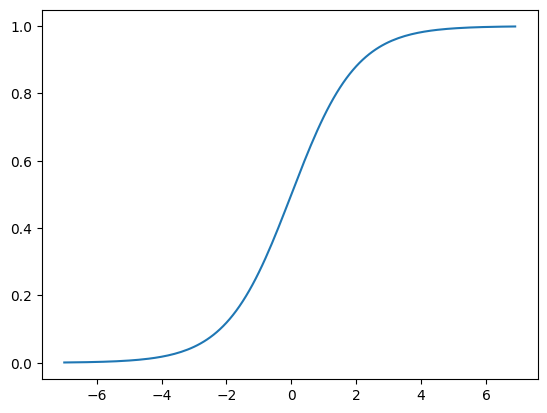

In [15]:
# Codigo bonito aquí 🪴
def sigmoid(z: np.array):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
sigma_z = sigmoid(z)
plt.plot(z, sigma_z)

### ❓ Qué hará la función $sigmoid$?

- Convertir de $\mathbb{R}$ al rango `[0-1]`

### Diferencias con adaline

<center><img src="img/logistic_regression_arch.png" width=500></center>

> Tomada de ML con Pytorch y Scikit-Learn, Raschka et. al 

- La salida de la función *sigmoid* puede interpretarse como la probabilidad de que un ejemplo particular pertenezca a la clase 1 $\sigma(z) = p(y=1|\textbf{x};w,b)$

### ❓ Que quiere decir $\sigma(z) = 0.8$ para nuestro dataset iris binario? 

- La probabilidad de que nuestra flor sea `versicolor` es del $80\%$
- Por lo tanto, la probabilidad de que sea `setosa` será: $ p(y=0|\textbf{x};w,b) =  1 - p(y=1|\textbf{x};w,b) = 20\%$

$$
\hat{y} = \begin{cases}
    1 & \sigma(z) \geq 0.5\\
    0 & \text{otro caso}
\end{cases}
$$

$$
\hat{y} = \begin{cases}
    1 & z \geq 0.0\\
    0 & \text{otro caso}
\end{cases}
$$

Hay muchas aplicaciones donde es de interés, no solo la clase predicha, si no tambien la probabilidad del evento. Ej: La probabilidad de que llueva ⛈️

### Reglas de aprendizaje de la regresión logística

- En este caso utilizaremos la función *likelihood* $\mathcal{L}$, que en este caso queremos maximizar, para obtener el *loss*.

$$
\begin{align}
\mathcal{L}(\textbf{w},b|\textbf{x}) = p(y|\textbf{x};w,b) \\
\mathcal{L}(\textbf{w},b|\textbf{x}) = \prod_{i=1}^{n}p(y^{(i)}|\textbf{x}^{(i)};w,b)\\
\mathcal{L}(\textbf{w},b|\textbf{x}) = \prod_{i=1}^{n}(\sigma(z^{(i)}))^{y^{(i)}}(1-\sigma(z^{(i)}))^{1-y^{(i)}}
\end{align}
$$

- En principio se maximiza el log de esta ecuación, que es conocida como la función **log-likelihood**:

$$
\begin{align}
l(\textbf{w},b|\textbf{x}) = \log\mathcal{L}(\textbf{w},b|\textbf{x}) \\
l(\textbf{w},b|\textbf{x}) = \sum_{i=1} [y^{(i)}\log(\sigma(z^{(i)}))+(1-y^{(i)})\log(1-\sigma(z^{(i)}))]
\end{align}
$$
> Aplicar la función $log$ reduce el potencial *numerical overflow*, que puede ocurrir cuando los *likelihoods* son muy pequeños. Tembien, convertimos los productos por sumas de factorews, que hace que obtener la derivada sea más sencillo.

- Reescribiendo la función *log-likelihood* como una función que pueda ser minimizada por el decenso del gradiente obtendremos lo siguiente:

$$
L(\textbf{w},b) = \sum_{i=1}^n [-y^{(i)}\log(\sigma(z^{(i)}))-(1-y^{(i)})\log(1-\sigma(z^{(i)}))]
$$

- Para un ejemplo concreto tendríamos lo siguiente:

$$
L(\sigma(z),y;\textbf{w},b) = -y\log(\sigma(z))-(1-y)\log(1-\sigma(z))
$$

por lo tanto

$$
L(\sigma(z),y;\textbf{w},b) = \begin{cases}
    -\log(\sigma(z)) & \text{if }y=1\\
    -\log(1-\sigma(x)) & \text{if }y=0
\end{cases}
$$

In [16]:
def loss_1(z):
    return -np.log(sigmoid(z))


def loss_0(z):
    return -np.log(1 - sigmoid(z))

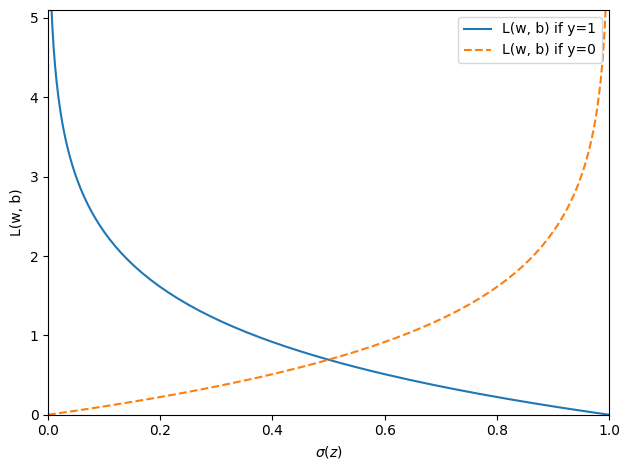

In [17]:
z = np.arange(-10, 10, 0.1)
sigma_z = sigmoid(z)
c1 = [loss_1(x) for x in z]
plt.plot(sigma_z, c1, label="L(w, b) if y=1")
c0 = [loss_0(x) for x in z]
plt.plot(sigma_z, c0, linestyle="--", label="L(w, b) if y=0")
plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel(r"$\sigma(z)$")
plt.ylabel("L(w, b)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

### Adaptando adaline para regresión logística

Para adaptar nuestro código adaline a la regresión logística bastará con modificar la función *loss* con la ecuación obtenida previamente:

$$
L(\textbf{w},b) = \frac{1}{n}\sum_{i=1}^n [-y^{(i)}\log(\sigma(z^{(i)}))-(1-y^{(i)})\log(1-\sigma(z^{(i)}))]
$$

Además, debemos adaptar la función de activación a la función sigmoide

In [18]:
class LogisticRegressionGD:
    """Clasificador Logistic Regression

    Parameters
    ------------
    eta : float
      Learning rate (entre 0.0 y 1.0)
    epochs : int
      Numero de pasos para entrenamiento.
    random_state : int
      Semilla para el generador de número aleatorios para
      inicialización de pesos
    
    Attributes
    -----------
    w: 1d-array
      Pesos despues del entrenamiento
    b : Scalar
      Bias unit despues del entrenamiento
    errors : list
      Número de clases incorrectamente clasificadas para cada epoch
    """

    def __init__(self, eta=0.01, epochs=100, random_state=42, verbose=False):
        self.eta = eta
        self.epochs = epochs
        self.random_state = random_state
        self.errors = []
        self.verbose = verbose
        
    def fit(self, X: np.array, y: np.array):
        random_gen = RandomState(self.random_state)
        # Generamos números pequeños de una distribución normal
        # con std=0.01 y media=0.0
        self.w = random_gen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # El bias será inicializado en 0
        self.b = np.float64(0.)
        
        for _ in range(self.epochs):
            # Aplicar la función de entrada
            forward = self.forward(X)
            # Aplicar la función de activación
            out = self.activation(forward)
            # Obtener los errores
            epoch_errors = (y - out)
            # Actualización de pesos
            self.w += self.eta * 2.0 * X.T.dot(epoch_errors) / X.shape[0]
            self.b += self.eta * 2.0 * epoch_errors.mean()
            # Log-likelihood
            loss = -y.dot(np.log(out)) - ((1 - y).dot(np.log(1 - out))) / X.shape[0]
            if self.verbose:
                print(f"EPOCH: {_} loss: {loss} | w={self.w} | b={self.b}")        
            self.errors.append(loss)
        return self

    def forward(self, X: np.array):
        """Calcula la entrada de la red"""
        return np.dot(X, self.w) + self.b

    def activation(self, z: np.array):
        """Capa de activación"""
        return 1.0 / (1.0 + np.exp(-z))
        
    def predict(self, X: np.array):
        """Función de decisión"""
        return np.where(self.forward(X) >= 0.5, 1, 0)

#### Probando la implementación

In [21]:
lrgd = LogisticRegressionGD(eta=0.3, epochs=1000, random_state=42)
lrgd.fit(X_norm, y)

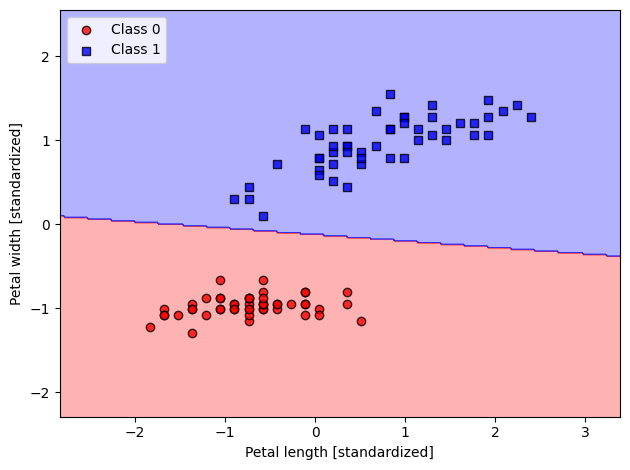

In [22]:
plot_decision_regions(X=X_norm, y=y, classifier=lrgd)
plt.xlabel("Petal length [standardized]")
plt.ylabel("Petal width [standardized]")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Regresión logística con `sklearn`

In [23]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [25]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100.0, solver="lbfgs", multi_class="ovr")

In [27]:
lr.fit(X_train_std, y_train)

/home/umoqnier/develop/lectures/Redes-Neuronales/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,100.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [28]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

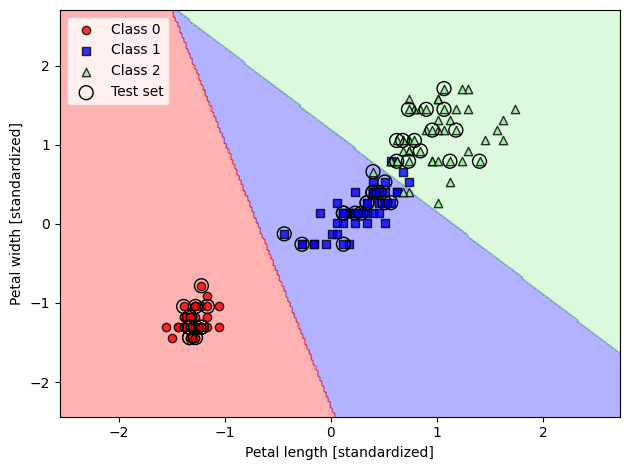

In [29]:
plot_decision_regions(
    X_combined_std, y_combined, classifier=lr, test_idx=range(105, 150)
)
plt.xlabel("Petal length [standardized]")
plt.ylabel("Petal width [standardized]")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [30]:
lr.predict_proba(X_test_std[:3, :])

array([[6.63770505e-09, 1.44747233e-01, 8.55252760e-01],
       [8.34031210e-01, 1.65968790e-01, 3.20815954e-13],
       [8.48822884e-01, 1.51177116e-01, 2.57998350e-14]])

In [32]:
lr.predict_proba(X_test_std[:3, :]).sum(axis=1)

array([1., 1., 1.])

### Retomando la práctica

In [34]:
class Node:
    def __call__(self, x):
        return self.forward(x)

    def __str__(self):
        return str(self.out)

In [39]:
class PreActivation(Node):

    def __init__(self, input_size, output_size):
        pass

In [36]:
class Sigmoid(Node):
    pass

In [37]:
class BinaryCrossEntropy(Node):
    pass

In [ ]:
from tqdm import tqdm

linear = PreActivation(2, 1)
sigmoid = Sigmoid()
criterion = BinaryCrossEntropy()

epochs = 100
lr = 0.1

for t in tqdm(range(epochs)):
    for x_i, y_i in zip(X_train_std, y_train):
        l = linear(x_i)
        f = sigmoid(l)

        loss = criterion(f, y_i)
        loss.backward()

        linear.w -= lr * l.grad
        linear.b -= lr * l.grad_b